In [22]:
import torch
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import arviz as az

from insilico_stimuli.stimuli import GaborSet

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")

In [26]:
def plot_samples(trace):
    fig, axs = plt.subplots(nrows=3, ncols=6, dpi=150, sharex=True, sharey=True)
    for idx, ax in enumerate(axs.ravel()):
        response = trace["neuron"][:, idx]
        if response.mean() > 0.2:
            color = "red"
        else:
            color = "blue"
        sns.histplot(
            trace["neuron"][:, idx].ravel(),
            color=color,
            stat="probability",
            element="step",
            ax=ax,
        )
        ax.text(
            0.7,
            0.6,
            f"{np.mean(trace['neuron'][:, idx].ravel()):.2f}",
            fontsize=6,
            transform=ax.transAxes,
        )
        ax.tick_params(axis="both", which="major", labelsize=5)
        # reduce the font size of the x and y labels
        ax.xaxis.label.set_size(5)
        ax.yaxis.label.set_size(5)
        # print the idx + 1 on the top right corner in small font
        ax.text(0.5, 0.9, f"{idx+1}", fontsize=6, transform=ax.transAxes)

In [24]:
def plot_correlation(trace):
    fig, ax = plt.subplots(dpi=150)
    sns.heatmap(np.corrcoef(trace["neuron"].T), ax=ax, cmap="viridis")
    # make it a square plot
    ax.set_aspect("equal")
    # reduce the tick size
    ax.tick_params(axis="both", which="major", labelsize=7)

In [4]:
gabor_data = torch.load("/src/project/computed/gabors.pt")
gabors = torch.tensor(gabor_data["gabors"].images()).float()

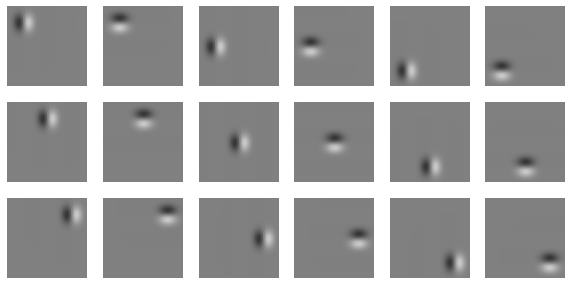

In [5]:
plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_data["gabors"].images()):
    plt.subplot(3, 6, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")

In [6]:
def sample_posterior(stimulus):
    z_dim = 18
    Lambda = torch.ones(z_dim)
    sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
        x = pm.Normal(
            "stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimulus
        )
        trace = pm.sample(1_000, return_inferencedata=False)
    return trace

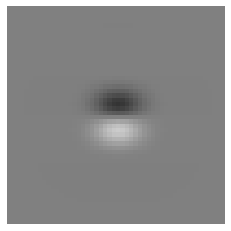

In [8]:
gabor_params_center = {
    "canvas_size": [50, 50],
    "sizes": [15],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": [[25, 25]],
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set_center = GaborSet(**gabor_params_center)
stimuli = torch.tensor(gabor_set_center.images()).float().sum(dim=0)
im = plt.imshow(stimuli, cmap="gray", vmin=-1, vmax=1)
ax = plt.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.


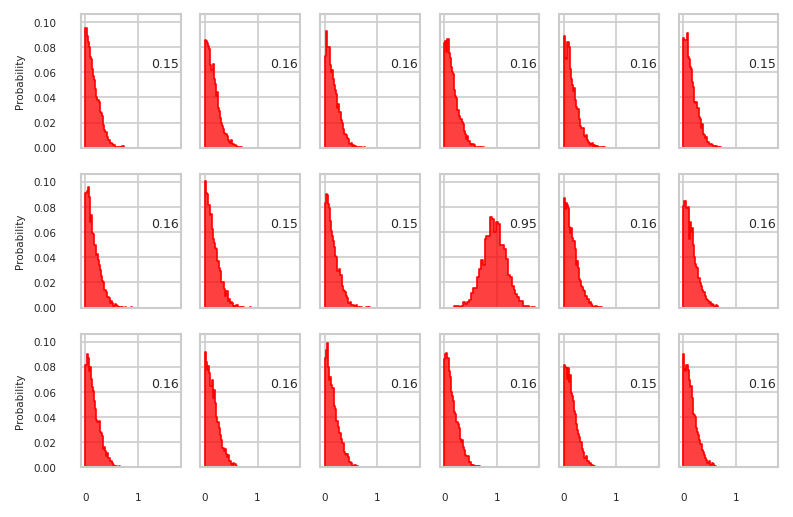

In [9]:
trace = sample_posterior(stimuli)

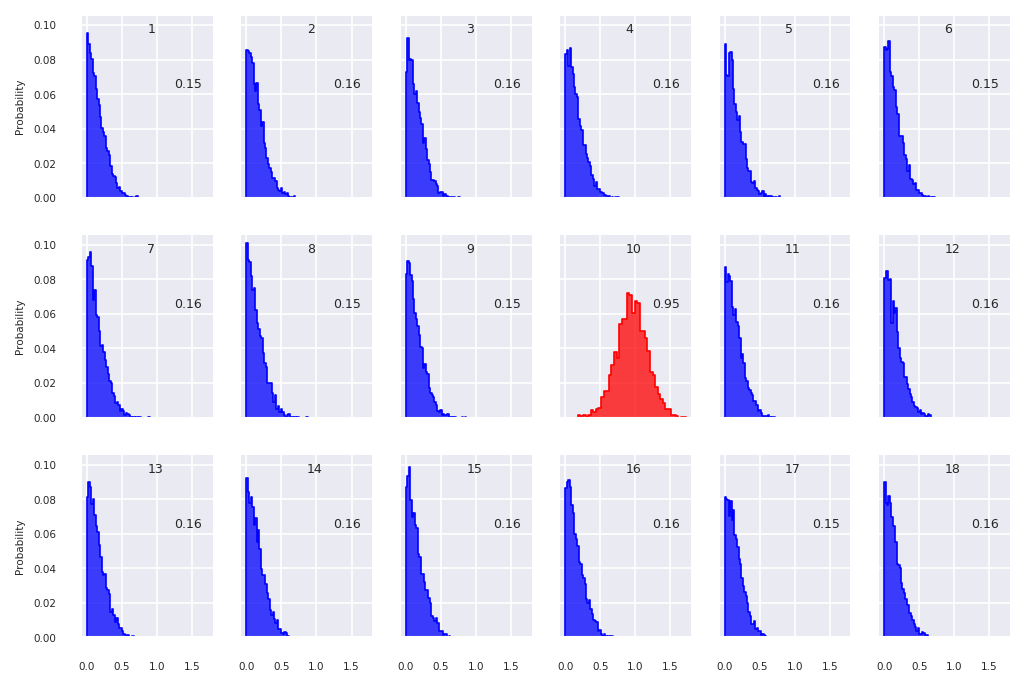

In [27]:
plot_samples(trace)

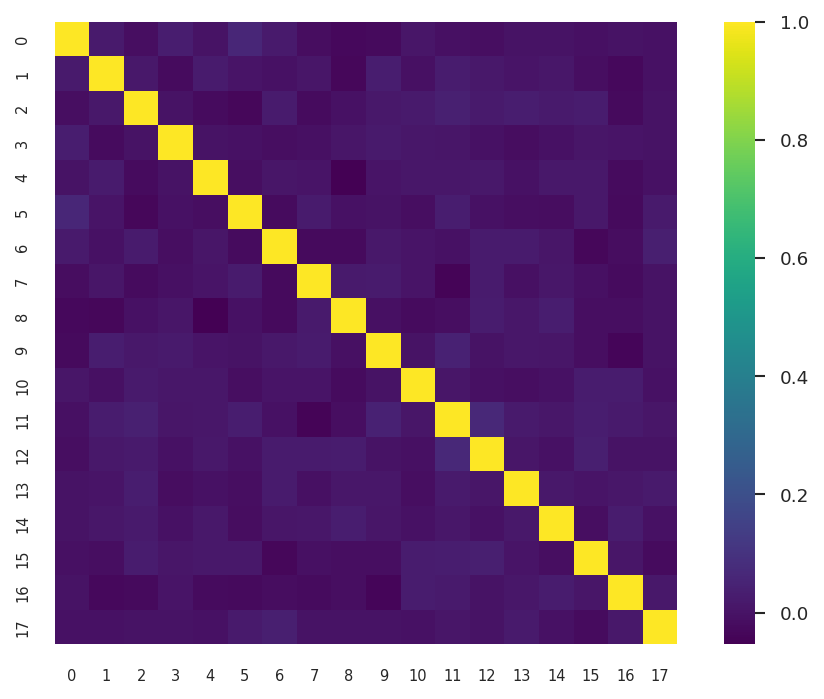

In [25]:
plot_correlation(trace)

In [ ]:
model = pm.Model()
with model:
    v = pm.VonMises("orientation", mu=0, kappa=1, shape=2)

    z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
    x = pm.Normal(
        "stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimulus
    )